<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/Regresi%C3%B3n_lineal_m%C3%B9%C3%BAtiple_con_datos_de_firjol_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto de los datos

El conjunto de datos corresponde a variables agronómicas medidas durante un ciclo de cultivo de frijol, cuyo objetivo es analizar los factores que influyen en la calidad del producto final, son alrededor de *1200* registros, estas son las variables independientes:

* *temperatura* es el promedio de la temperatura ambiental en un ciclo periodo de tiempo       
* *humedad* es el promedio de humedad de suelo en un ciclo de cultivo o periodo de tiempo   
* *precipitacion* es la cantidad de agua precipitada medida en un periodo de tiempo
* *nitrogeno* cantidad promedio de nitrógeno vertido como fertilizante promedio en un periodo de tiempo
* *fosforo* cantidad de promedio de fósfoto vertido como fertilizante en un periodo de tiempo
* *materia_organica* porcentaje de materia orgánica presente en el suelo, es como fertilziante.
* *horas_sol* cantidad de solo promedo medido en horas/dia  
* *tipo_suelo_arenoso* FALSO o VERDADERO su el tipo de suelo de los datos recabados es arenoso
* *tipo_suelo_franco* FALSO o VERDADERO su el tipo de suelo de los datos recabados es suelo franco o arcilloso.

La variable dependiente es *calidad_frijol* medido con valores aproximados entre 170 y 300, siendo valores altos de buena calidad y lo contrario con valores bajos.

El documento *notebook* se puede encontrar en el servicio *google collab* https://colab.research.google.com/drive/1AagRsq5NWuwFmLhwW250Bvaq_1RsgGJA?usp=sharing,

También se puede ubicar este documento en el servicio del autor *github.com* en https://github.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/Regresi%C3%B3n_lineal_m%C3%B9%C3%BAtiple_con_datos_de_firjol_pynb.ipynb

Los datos para su descarga se encuentran en el servico *github.com* https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/datos_frijol.csv.

Las funciones se pueden encontrar en el servicio *github.com* del autor: **pendiente**



# Objetivo

Implementar y evaluar un modelo de regresión lineal múltiple que permita predecir calidad de frijol mediante programación en *Python*.

Los datos deberán estar particionados en *70%* para datos de entrenamiento y *30%* para datos de validación

El modelo será óptimo si satisface los postulados de la regresión y si el valor de *r square adjustado* está por encima del *85%*.

# Descripción

Se sigue la metodología sugerida para todos los casos de estudio.

## Cargar librerías



In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from scipy.stats import shapiro
from scipy.stats import kstest

from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_reset

import statsmodels.api as sm

## Cargar funciones


In [2]:
# Funciones para implementar y evaluar modelos de regresión múltiple en Python
# Rubén Pizarro Gurrola
# Mayo 2026

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from scipy.stats import shapiro
from scipy.stats import kstest
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_reset
import statsmodels.api as sm

#========================================================
# CARGAR DATOS
#========================================================

def f_cargar_datos(ruta_archivo):

    datos = pd.read_csv(ruta_archivo)

    return datos

#========================================================
# VISUALIZAR HEAD Y TAIL
#========================================================

def f_visualizar_head_tail_reducido(
        datos,
        n = 6
):

    #----------------------------------------------------
    # Total columnas
    #----------------------------------------------------

    total_columnas = datos.shape[1]

    #----------------------------------------------------
    # Primeras 4 columnas
    #----------------------------------------------------

    idx_prim = list(
        range(
            min(4, total_columnas)
        )
    )

    #----------------------------------------------------
    # Últimas 4 columnas
    #----------------------------------------------------

    idx_ult = list(
        range(
            max(total_columnas - 4, 0),
            total_columnas
        )
    )

    #----------------------------------------------------
    # Evitar duplicados
    #----------------------------------------------------

    idx_ult = [
        i for i in idx_ult
        if i not in idx_prim
    ]

    #----------------------------------------------------
    # Subconjuntos
    #----------------------------------------------------

    datos_prim = datos.iloc[:, idx_prim]

    datos_ult = datos.iloc[:, idx_ult]

    #----------------------------------------------------
    # HEAD
    #----------------------------------------------------

    head_prim = (
        datos_prim
        .head(n)
        .astype(str)
        .reset_index(drop = True)
    )

    head_ult = (
        datos_ult
        .head(n)
        .astype(str)
        .reset_index(drop = True)
    )

    #----------------------------------------------------
    # TAIL
    #----------------------------------------------------

    tail_prim = (
        datos_prim
        .tail(n)
        .astype(str)
        .reset_index(drop = True)
    )

    tail_ult = (
        datos_ult
        .tail(n)
        .astype(str)
        .reset_index(drop = True)
    )

    #----------------------------------------------------
    # Separadores
    #----------------------------------------------------

    sep_head = pd.DataFrame({
        "...": ["..."] * n
    })

    sep_tail = pd.DataFrame({
        "...": ["..."] * n
    })

    #----------------------------------------------------
    # Combinar HEAD
    #----------------------------------------------------

    head_comb = pd.concat(

        [
            head_prim,
            sep_head,
            head_ult
        ],

        axis = 1
    )

    #----------------------------------------------------
    # Combinar TAIL
    #----------------------------------------------------

    tail_comb = pd.concat(

        [
            tail_prim,
            sep_tail,
            tail_ult
        ],

        axis = 1
    )

    #----------------------------------------------------
    # Fila separadora
    #----------------------------------------------------

    fila_sep = pd.DataFrame(

        [["..."] * head_comb.shape[1]],

        columns = head_comb.columns
    )

    #----------------------------------------------------
    # Tabla final
    #----------------------------------------------------

    tabla = pd.concat(

        [
            head_comb,
            fila_sep,
            tail_comb
        ],

        ignore_index = True
    )

    return tabla

#========================================================
# DESCRIBIR DATOS
#========================================================

def f_describir_datos(datos):

    describe = datos.describe(include = 'all')

    structure = datos.dtypes

    return {
        "describe": describe,
        "structure": structure
    }

def f_convertir_dummis(datos, variable_dependiente):

    #----------------------------------------------------------
    # f_convertir_dummis()
    #
    # Objetivo:
    #   Convertir variables categóricas y booleanas
    #   a variables dummy, manteniendo la variable
    #   dependiente al final del DataFrame.
    #
    # Argumentos:
    #   datos                : DataFrame de pandas
    #   variable_dependiente : nombre de la variable objetivo
    #
    # Valor de retorno:
    #   DataFrame transformado
    #
    #----------------------------------------------------------

    import pandas as pd


    #----------------------------------------------------------
    # Copiar datos
    #----------------------------------------------------------

    datos_dummis = datos.copy()


    #----------------------------------------------------------
    # Guardar variable dependiente
    #----------------------------------------------------------

    y = datos_dummis[variable_dependiente]


    #----------------------------------------------------------
    # Eliminar temporalmente variable dependiente
    #----------------------------------------------------------

    datos_dummis = datos_dummis.drop(
        columns = [variable_dependiente]
    )


    #----------------------------------------------------------
    # Detectar variables categóricas y booleanas
    #----------------------------------------------------------

    variables_convertir = datos_dummis.select_dtypes(
        include = ["object", "bool"]
    ).columns


    #----------------------------------------------------------
    # Convertir a variables dummy
    #----------------------------------------------------------

    datos_dummis = pd.get_dummies(
        datos_dummis,
        columns = variables_convertir,
        drop_first = True,
        dtype = int
    )


    #----------------------------------------------------------
    # Agregar variable dependiente al final
    #----------------------------------------------------------

    datos_dummis[variable_dependiente] = y


    #----------------------------------------------------------
    # Devolver resultado
    #----------------------------------------------------------

    return datos_dummis

#========================================================
# PARTICIONAR DATOS
#========================================================

def f_particionar_datos(datos,
                         proporcion_entrenamiento = 0.7):

    datos_entrenamiento, datos_validacion = train_test_split(
        datos,
        train_size = proporcion_entrenamiento,
        random_state = 2026
    )

    return {
        "datos_entrenamiento": datos_entrenamiento,
        "datos_validacion": datos_validacion
    }

#========================================================
# CONVERTIR FACTOR
#========================================================

def f_convertir_factor(datos):

    datos_mod = datos.copy()

    for col in datos_mod.columns:

        if datos_mod[col].dtype == 'object':

            datos_mod[col] = datos_mod[col].astype('category')

        if datos_mod[col].dtype == 'bool':

            datos_mod[col] = datos_mod[col].astype(int)

    return datos_mod

#========================================================
# REDONDEAR VARIABLES NUMÉRICAS
#========================================================

def f_redondear_numericas(datos,
                          decimales = 2):

    datos_out = datos.copy()

    columnas_num = datos_out.select_dtypes(include = np.number).columns

    datos_out[columnas_num] = datos_out[columnas_num].round(decimales)

    return datos_out

#========================================================
# MODELO REGRESIÓN LINEAL MÚLTIPLE
#========================================================

def f_construir_modelo_RLM(datos,
                           variable_dependiente,
                           ver_resumen = True):

    X = datos.drop(columns = [variable_dependiente])

    y = datos[variable_dependiente]

    X = pd.get_dummies(X,
                       drop_first = True)

    modelo = LinearRegression()

    modelo.fit(X, y)

    if ver_resumen:

        X_sm = sm.add_constant(X)

        modelo_sm = sm.OLS(y, X_sm).fit()

        print(modelo_sm.summary())

    return modelo

#========================================================
# MODELO REGRESIÓN LINEAL MÚLTIPLE
# CON STATSMODELS
#========================================================

def f_construir_modelo_RLM_statsmodels(

        datos,

        variable_dependiente,

        ver_resumen = True
):

    #----------------------------------------------------
    # Variables independientes
    #----------------------------------------------------

    X = datos.drop(
        columns = [variable_dependiente]
    )

    #----------------------------------------------------
    # Variable dependiente
    #----------------------------------------------------

    y = datos[variable_dependiente]

    #----------------------------------------------------
    # Variables dummy
    #----------------------------------------------------

    X = pd.get_dummies(

        X,

        drop_first = True
    )

    #----------------------------------------------------
    # Constante
    #----------------------------------------------------

    X = sm.add_constant(X)

    #----------------------------------------------------
    # Modelo OLS
    #----------------------------------------------------

    modelo = sm.OLS(

        y,

        X

    ).fit()

    #----------------------------------------------------
    # Resumen
    #----------------------------------------------------

    if ver_resumen:

        print(modelo.summary())

    return modelo

#========================================================
# MODELO POLINOMIAL MÚLTIPLE
#========================================================

def f_multiple_polinomial(datos,
                          variable_dependiente,
                          orden = 2,
                          ver_resumen = True):

    X = datos.drop(columns = [variable_dependiente])

    y = datos[variable_dependiente]

    X = pd.get_dummies(X,
                       drop_first = True)

    poly = PolynomialFeatures(
        degree = orden,
        include_bias = False
    )

    X_poly = poly.fit_transform(X)

    modelo = LinearRegression()

    modelo.fit(X_poly, y)

    if ver_resumen:

        print("\n============================")
        print(f"Modelo Polinomial Orden {orden}")
        print("============================")

        print("Número de términos:", X_poly.shape[1])

    return {
        "modelo": modelo,
        "poly": poly
    }

#========================================================
# ESTANDARIZAR Y ESCALAR
#========================================================

def f_estandarizar_escalar(datos,
                           decimales = 4):

    datos_est = datos.copy()
    datos_esc = datos.copy()

    columnas_num = datos.select_dtypes(include = np.number).columns

    scaler_est = StandardScaler()

    scaler_minmax = MinMaxScaler()

    datos_est[columnas_num] = np.round(
        scaler_est.fit_transform(datos[columnas_num]),
        decimales
    )

    datos_esc[columnas_num] = np.round(
        scaler_minmax.fit_transform(datos[columnas_num]),
        decimales
    )

    return {
        "datos_estandarizados": datos_est,
        "datos_escalados": datos_esc
    }

#========================================================
# MODELO LASSO
#========================================================

def f_construir_modelo_lasso(datos,
                             variable_dependiente,
                             ver_resumen = True):

    X = datos.drop(columns = [variable_dependiente])

    y = datos[variable_dependiente]

    X = pd.get_dummies(X,
                       drop_first = True)

    modelo = LassoCV(
        cv = 10,
        random_state = 2026
    )

    modelo.fit(X, y)

    if ver_resumen:

        print("\n============================")
        print("Modelo LASSO")
        print("============================")

        print("Lambda óptimo:", modelo.alpha_)

        print("Coeficientes:")
        print(modelo.coef_)

    return modelo

#========================================================
# MODELO RIDGE
#========================================================

def f_construir_modelo_ridge(datos,
                             variable_dependiente,
                             ver_resumen = True):

    X = datos.drop(columns = [variable_dependiente])

    y = datos[variable_dependiente]

    X = pd.get_dummies(X,
                       drop_first = True)

    alphas = np.logspace(-4, 4, 100)

    modelo = RidgeCV(
        alphas = alphas,
        cv = 10
    )

    modelo.fit(X, y)

    if ver_resumen:

        print("\n============================")
        print("Modelo RIDGE")
        print("============================")

        print("Lambda óptimo:", modelo.alpha_)

        print("Coeficientes:")
        print(modelo.coef_)

    return modelo

#========================================================
# MULTICOLINEALIDAD VIF
#========================================================

def f_multicolinealidad(datos,
                        variable_dependiente):

    X = datos.drop(columns = [variable_dependiente])

    X = pd.get_dummies(X,
                       drop_first = True)

    X = sm.add_constant(X)

    vif = pd.DataFrame()

    vif["Variable"] = X.columns

    vif["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    return vif

#========================================================
# DIAGNÓSTICO DE LINEALIDAD
#========================================================

def f_linealidad(modelo):

    #----------------------------------------------------
    # Valores ajustados
    #----------------------------------------------------

    ajustados = modelo.fittedvalues

    #----------------------------------------------------
    # Residuos
    #----------------------------------------------------

    residuos = modelo.resid

    #----------------------------------------------------
    # Gráfico
    #----------------------------------------------------

    plt.figure(

        figsize = (6,4)
    )

    plt.scatter(

        ajustados,

        residuos,

        color = "blue"
    )

    plt.axhline(

        0,

        linestyle = "--",

        color = "red"
    )

    plt.title(

        "Residuos vs Valores Ajustados"
    )

    plt.xlabel(

        "Valores ajustados"
    )

    plt.ylabel(

        "Residuos"
    )

    plt.show()

    #----------------------------------------------------
    # Interpretación
    #----------------------------------------------------

    print("\n============================")

    print("Diagnóstico de Linealidad")

    print("============================")

    print(
        "- Los residuos deben distribuirse "
        "aleatoriamente alrededor de 0."
    )

    print(
        "- No deben observarse patrones "
        "curvos."
    )

    print(
        "- Curvaturas sugieren "
        "no linealidad."
    )

#========================================================
# TEST DE LINEALIDAD
# RAMSEY RESET
#========================================================

def f_linealidad_test(

        modelo

):

    #----------------------------------------------------
    # Ramsey RESET
    #----------------------------------------------------

    resultado = linear_reset(

        modelo,

        power = 2,

        use_f = True
    )

    #----------------------------------------------------
    # Mostrar resultado
    #----------------------------------------------------

    print("\n============================")

    print("Test de Linealidad (Ramsey RESET)")

    print("============================")

    print(resultado)

    #----------------------------------------------------
    # Interpretación
    #----------------------------------------------------

    p_valor = resultado.pvalue

    print("\nInterpretación:")

    if p_valor > 0.05:

        print(
            "✔ No se rechaza H0 → "
            "El modelo es lineal "
            "(no hay evidencia de curvatura)"
        )

    else:

        print(
            "❌ Se rechaza H0 → "
            "Existe evidencia de no linealidad"
        )

    return resultado

#========================================================
# HOMOCEDASTICIDAD
#========================================================

def f_homocedasticidad(

        modelo

):

    #----------------------------------------------------
    # Residuos
    #----------------------------------------------------

    residuos = modelo.resid

    #----------------------------------------------------
    # Valores ajustados
    #----------------------------------------------------

    ajustados = modelo.fittedvalues

    #----------------------------------------------------
    # Matriz X usada en el modelo
    #----------------------------------------------------

    X = modelo.model.exog

    #----------------------------------------------------
    # Breusch-Pagan
    #----------------------------------------------------

    bp = het_breuschpagan(

        residuos,

        X
    )

    #----------------------------------------------------
    # Resultados
    #----------------------------------------------------

    resultado = pd.DataFrame({

        "Prueba": [

            "Breusch-Pagan"
        ],

        "LM Statistic": [

            round(bp[0], 4)
        ],

        "LM p-value": [

            round(bp[1], 4)
        ],

        "F Statistic": [

            round(bp[2], 4)
        ],

        "F p-value": [

            round(bp[3], 4)
        ]
    })

    #----------------------------------------------------
    # Gráfico
    #----------------------------------------------------

    plt.figure(

        figsize = (6,4)
    )

    plt.scatter(

        ajustados,

        residuos,

        color = "blue"
    )

    plt.axhline(

        0,

        linestyle = "--",

        color = "red"
    )

    plt.title(

        "Residuos vs Valores Ajustados"
    )

    plt.xlabel(

        "Valores ajustados"
    )

    plt.ylabel(

        "Residuos"
    )

    plt.show()

    #----------------------------------------------------
    # Interpretación
    #----------------------------------------------------

    print("\n============================")

    print("Diagnóstico de Homocedasticidad")

    print("============================")

    print(resultado)

    print("\nInterpretación:")

    if bp[1] > 0.05:

        print(
            "✔ No se rechaza H0 → "
            "Existe homocedasticidad"
        )

    else:

        print(
            "❌ Se rechaza H0 → "
            "Existe heterocedasticidad"
        )

    return resultado

#========================================================
# NORMALIDAD DE RESIDUOS
#========================================================

from scipy.stats import shapiro
from scipy.stats import kstest
from scipy.stats import anderson

def f_normalidad(

        modelo

):

    #----------------------------------------------------
    # Residuos estandarizados
    #----------------------------------------------------

    residuos = modelo.resid

    residuos = (

        residuos - np.mean(residuos)

    ) / np.std(residuos)

    #----------------------------------------------------
    # SHAPIRO-WILK
    #----------------------------------------------------

    shapiro_test = shapiro(

        residuos
    )

    #----------------------------------------------------
    # KOLMOGOROV-SMIRNOV
    #----------------------------------------------------

    ks_test = kstest(

        residuos,

        'norm'
    )

    #----------------------------------------------------
    # ANDERSON-DARLING
    #----------------------------------------------------

    ad_test = anderson(

        residuos,

        dist = 'norm'
    )

    #----------------------------------------------------
    # Aproximación interpretación
    # scipy no devuelve p-value directo
    # usamos nivel 5%
    #----------------------------------------------------

    ad_critico_5 = ad_test.critical_values[2]

    ad_interpretacion = (

        "Normalidad"

        if ad_test.statistic < ad_critico_5

        else

        "No normalidad"
    )

    #----------------------------------------------------
    # RESULTADOS
    #----------------------------------------------------

    resultado = pd.DataFrame({

        "Prueba": [

            "Shapiro-Wilk",

            "Kolmogorov-Smirnov",

            "Anderson-Darling"
        ],

        "Estadistico": [

            round(shapiro_test.statistic, 4),

            round(ks_test.statistic, 4),

            round(ad_test.statistic, 4)
        ],

        "p_value": [

            round(shapiro_test.pvalue, 4),

            round(ks_test.pvalue, 4),

            np.nan
        ],

        "Interpretacion": [

            "Normalidad"

            if shapiro_test.pvalue > 0.05

            else

            "No normalidad",

            "Normalidad"

            if ks_test.pvalue > 0.05

            else

            "No normalidad",

            ad_interpretacion
        ]
    })

    #----------------------------------------------------
    # HISTOGRAMA
    #----------------------------------------------------

    plt.figure(

        figsize = (6,4)
    )

    plt.hist(

        residuos,

        bins = 15,

        density = True,

        alpha = 0.7
    )

    plt.title(

        "Histograma de residuos"
    )

    plt.xlabel(

        "Residuos estandarizados"
    )

    plt.ylabel(

        "Frecuencia"
    )

    plt.show()

    #----------------------------------------------------
    # QQ-PLOT
    #----------------------------------------------------

    sm.qqplot(

        residuos,

        line = '45'
    )

    plt.title(

        "QQ-Plot residuos"
    )

    plt.show()

    #----------------------------------------------------
    # RESULTADOS
    #----------------------------------------------------

    print("\n============================")

    print("Diagnóstico de Normalidad")

    print("============================")

    print(resultado)

    #----------------------------------------------------
    # Anderson detalle
    #----------------------------------------------------

    print("\nAnderson-Darling:")

    print(

        f"Estadístico = "
        f"{round(ad_test.statistic,4)}"
    )

    print(

        f"Valor crítico 5% = "
        f"{round(ad_critico_5,4)}"
    )

    print("\nInterpretación:")

    for i in range(len(resultado)):

        prueba = resultado.iloc[i]["Prueba"]

        interpretacion = resultado.iloc[i]["Interpretacion"]

        if interpretacion == "Normalidad":

            print(

                f"✔ {prueba}: Normalidad"
            )

        else:

            print(

                f"❌ {prueba}: No normalidad"
            )

    return resultado


#========================================================
# INDEPENDENCIA DE RESIDUOS
#========================================================

from statsmodels.stats.stattools import durbin_watson

def f_independencia(

        modelo

):

    #----------------------------------------------------
    # Residuos
    #----------------------------------------------------

    residuos = modelo.resid

    #----------------------------------------------------
    # Durbin-Watson
    #----------------------------------------------------

    dw = durbin_watson(

        residuos
    )

    #----------------------------------------------------
    # DataFrame resultado
    #----------------------------------------------------

    resultado = pd.DataFrame({

        "Prueba": [

            "Durbin-Watson"
        ],

        "Estadistico": [

            round(dw,4)
        ],

        "Interpretacion": [

            "Sin autocorrelación"

            if 1.5 <= dw <= 2.5

            else

            "Posible autocorrelación"
        ]
    })

    #----------------------------------------------------
    # Gráfico residuos
    #----------------------------------------------------

    plt.figure(

        figsize = (7,4)
    )

    plt.plot(

        residuos,

        color = "black",

        linewidth = 1
    )

    plt.axhline(

        0,

        linestyle = "--",

        color = "red"
    )

    plt.title(

        "Residuos en secuencia"
    )

    plt.xlabel(

        "Observación"
    )

    plt.ylabel(

        "Residuo"
    )

    plt.show()

    #----------------------------------------------------
    # Resultados
    #----------------------------------------------------

    print("\n============================")

    print("Diagnóstico de Independencia")

    print("============================")

    print(resultado)

    #----------------------------------------------------
    # Interpretación ampliada
    #----------------------------------------------------

    print("\nInterpretación:")

    if 1.5 <= dw <= 2.5:

        print(
            "✔ No existe evidencia "
            "de autocorrelación"
        )

    elif dw < 1.5:

        print(
            "❌ Existe posible "
            "autocorrelación positiva"
        )

    else:

        print(
            "❌ Existe posible "
            "autocorrelación negativa"
        )

    return resultado

#========================================================
# ECUACIÓN DEL MODELO
#========================================================

def f_ecuacion_modelo(

        modelo,

        redondeo = 4

):

    #----------------------------------------------------
    # Coeficientes
    #----------------------------------------------------

    coefs = modelo.params

    #----------------------------------------------------
    # Redondear
    #----------------------------------------------------

    coefs = round(

        coefs,

        redondeo
    )

    #----------------------------------------------------
    # Intercepto
    #----------------------------------------------------

    intercepto = coefs.iloc[0]

    ecuacion = f"ŷ = {intercepto}"

    #----------------------------------------------------
    # Construcción términos
    #----------------------------------------------------

    for variable in coefs.index[1:]:

        valor = coefs[variable]

        signo = (

            " + "

            if valor >= 0

            else

            " - "
        )

        termino = (

            f"{signo}"

            f"{abs(valor)}"

            f"*{variable}"
        )

        ecuacion += termino

    #----------------------------------------------------
    # Mostrar
    #----------------------------------------------------

    print("\n============================")

    print("ECUACIÓN DEL MODELO")

    print("============================\n")

    print(ecuacion)

    return ecuacion

#========================================================
# EVALUACIÓN DEL MODELO
#========================================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

def f_evaluacion_modelo(

        modelo,

        datos_validacion,

        variable_dependiente,

        redondeo = 4

):

    #----------------------------------------------------
    # Variable dependiente real
    #----------------------------------------------------

    y_real = datos_validacion[
        variable_dependiente
    ]

    #----------------------------------------------------
    # Variables independientes
    #----------------------------------------------------

    X_val = datos_validacion.drop(
        columns = [variable_dependiente]
    )

    #----------------------------------------------------
    # Variables dummy
    #----------------------------------------------------

    X_val = pd.get_dummies(

        X_val,

        drop_first = True
    )

    #----------------------------------------------------
    # Agregar constante
    #----------------------------------------------------

    X_val = sm.add_constant(

        X_val,

        has_constant = "add"
    )

    #----------------------------------------------------
    # Reordenar columnas
    # IMPORTANTÍSIMO
    #----------------------------------------------------

    X_val = X_val.reindex(

        columns = modelo.model.exog_names,

        fill_value = 0
    )

    #----------------------------------------------------
    # Predicciones
    #----------------------------------------------------

    pred = modelo.predict(

        X_val
    )

    #----------------------------------------------------
    # MÉTRICAS
    #----------------------------------------------------

    mse = mean_squared_error(

        y_real,

        pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(

        y_real,

        pred
    )

    r2 = r2_score(

        y_real,

        pred
    )

    #----------------------------------------------------
    # R² AJUSTADO
    #----------------------------------------------------

    n = len(y_real)

    p = X_val.shape[1] - 1

    r2_adj = 1 - (

        (1 - r2)

        * (n - 1)

        / (n - p - 1)
    )

    #----------------------------------------------------
    # RESULTADOS
    #----------------------------------------------------

    resultado = pd.DataFrame({

        "R_square": [

            round(r2, redondeo)
        ],

        "R_square_ajustado": [

            round(r2_adj, redondeo)
        ],

        "MSE": [

            round(mse, redondeo)
        ],

        "RMSE": [

            round(rmse, redondeo)
        ],

        "MAE": [

            round(mae, redondeo)
        ]
    })

    #----------------------------------------------------
    # Mostrar
    #----------------------------------------------------

    print("\n============================")

    print("Evaluación del Modelo")

    print("============================")

    print(resultado)

    return resultado


## Cargar datos


In [3]:
url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/datos_frijol.csv"
datos = f_cargar_datos(url)

## Visualizar datos


In [4]:
f_visualizar_head_tail_reducido(datos)

,temperatura,humedad,precipitacion,nitrogeno,...,horas_sol,tipo_suelo_arenoso,tipo_suelo_franco,calidad_frijol
0,23.7,62.41,115.66,126.84,...,9,False,False,267
1,20.82,47.46,126.49,85.05,...,9,True,False,209
2,25.93,76.44,122.39,82.71,...,7,True,False,241
3,24.96,63.91,106.36,99.0,...,7,False,False,236
4,29.35,52.56,77.93,136.32,...,9,True,False,260
5,25.89,41.49,111.89,80.13,...,6,False,False,222
6,...,...,...,...,...,...,...,...,...
7,25.19,57.35,99.24,141.5,...,8,True,False,272
8,26.8,47.17,128.42,132.78,...,9,False,False,258
9,32.07,53.04,70.02,54.24,...,9,True,False,214


## Describir datos

Se ejecuta la función *f_describir_datos()* y la descripción estadística en modo consola.

In [5]:
f_describir_datos(datos)

{'describe':         temperatura      humedad  precipitacion    nitrogeno      fosforo  \
 count   1200.000000  1200.000000    1200.000000  1200.000000  1200.000000   
 unique          NaN          NaN            NaN          NaN          NaN   
 top             NaN          NaN            NaN          NaN          NaN   
 freq            NaN          NaN            NaN          NaN          NaN   
 mean      25.177658    59.766958     100.800058    99.488692    64.522067   
 std        3.131361    11.618205      20.303565    28.859846    20.123592   
 min       14.600000    40.020000      32.110000    50.020000    30.180000   
 25%       23.190000    49.635000      87.120000    74.012500    47.415000   
 50%       25.180000    60.000000     100.900000    99.885000    65.495000   
 75%       27.262500    70.152500     114.860000   124.297500    81.460000   
 max       35.830000    79.990000     164.300000   149.660000    99.930000   
 
         materia_organica    horas_sol tipo_suelo_

## Transformar datos

Se generan datos limpios a partir de los datos originales y se deja en la variable llamada *datos_limpios*.

La estrategia es generar variables *dummis* para las variables booleanas *tipo_suelo_arenoso* y *tipo_suelo_franco*, el resultado de la función *f_convertir_dummis()* es que modifica los nombres de las variables y las codifica: la variable nueva *tipo_suelo_arenoso_True* se codifica a *1* cuando es *True* y *0* cuando es *False*; lo mismo sucede con la variable *tipo_suelo_franco_True*, esto ayudará a construir de manera más eficiente el modelo además de que así lo exige la construccón del modelo en *Python*.


In [6]:
datos_limpios = f_convertir_dummis(datos, "calidad_frijol")
f_visualizar_head_tail_reducido(datos_limpios)

,temperatura,humedad,precipitacion,nitrogeno,...,horas_sol,tipo_suelo_arenoso_True,tipo_suelo_franco_True,calidad_frijol
0,23.7,62.41,115.66,126.84,...,9,0,0,267
1,20.82,47.46,126.49,85.05,...,9,1,0,209
2,25.93,76.44,122.39,82.71,...,7,1,0,241
3,24.96,63.91,106.36,99.0,...,7,0,0,236
4,29.35,52.56,77.93,136.32,...,9,1,0,260
5,25.89,41.49,111.89,80.13,...,6,0,0,222
6,...,...,...,...,...,...,...,...,...
7,25.19,57.35,99.24,141.5,...,8,1,0,272
8,26.8,47.17,128.42,132.78,...,9,0,0,258
9,32.07,53.04,70.02,54.24,...,9,1,0,214


# Desarrollo


## Construir modelo de regresión lineal múltiple

### Particonamiento de los datos

Llamando la función *f_particionar_datos(), se construyen los datos de entrenamiento y datos de validación, *70%* y *30%* respectivamente y se visualizan los primeros y últimos registros de ambas particiones con la función *f_visualizar_head_tail_reducido(datos_entrenamiento)* y *f_visualizar_head_tail_reducido(datos_validacion)*.

In [7]:
particion = f_particionar_datos(datos_limpios)

datos_entrenamiento = particion["datos_entrenamiento"]
datos_validacion = particion["datos_validacion"]

f_visualizar_head_tail_reducido(datos_entrenamiento)



,temperatura,humedad,precipitacion,nitrogeno,...,horas_sol,tipo_suelo_arenoso_True,tipo_suelo_franco_True,calidad_frijol
0,28.06,74.19,67.62,83.27,...,9,1,0,229
1,31.27,69.32,121.99,143.12,...,8,1,0,268
2,30.41,61.18,86.69,137.92,...,7,0,1,258
3,27.01,60.87,105.55,132.11,...,9,0,1,272
4,26.48,79.57,56.65,136.57,...,7,1,0,271
5,22.0,41.38,98.23,92.82,...,8,1,0,212
6,...,...,...,...,...,...,...,...,...
7,30.37,68.06,114.36,131.53,...,9,1,0,253
8,19.53,40.22,78.72,100.64,...,6,1,0,195
9,25.65,66.05,129.44,140.37,...,10,0,1,287


In [8]:
f_visualizar_head_tail_reducido(datos_validacion)

,temperatura,humedad,precipitacion,nitrogeno,...,horas_sol,tipo_suelo_arenoso_True,tipo_suelo_franco_True,calidad_frijol
0,20.72,68.1,155.2,147.74,...,7,0,0,274
1,25.57,65.44,100.44,99.86,...,7,0,1,242
2,23.7,63.12,107.77,82.2,...,7,0,1,227
3,26.8,47.17,128.42,132.78,...,9,0,0,258
4,29.29,57.64,114.93,96.79,...,6,0,0,219
5,25.27,72.75,100.37,67.45,...,9,1,0,247
6,...,...,...,...,...,...,...,...,...
7,25.38,73.59,137.17,140.44,...,7,1,0,267
8,26.73,47.67,92.36,75.28,...,7,0,1,206
9,29.99,65.86,94.4,62.11,...,7,1,0,229


### Construir modelo de regresión lineal múltiple

Se construhye el modeo de regresión lineal múltipel con los datos de entrenamiento mandando llamar la función f_)=


In [9]:
modelo_RLM = f_construir_modelo_RLM_statsmodels(datos_entrenamiento, "calidad_frijol")

                            OLS Regression Results                            
Dep. Variable:         calidad_frijol   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     1587.
Date:                Sat, 16 May 2026   Prob (F-statistic):               0.00
Time:                        02:38:56   Log-Likelihood:                -2537.8
No. Observations:                 840   AIC:                             5096.
Df Residuals:                     830   BIC:                             5143.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

## Postulados del modelo

### Multicolinealidad

Al ejecutar la función *f_multicolinealidad()*, se observa que los valores del estadístico *VIF* están alrededor de *1* en todas las variables independientes lo que asegura que no existe multicolealidad en el modelo.

In [10]:
f_multicolinealidad (datos_entrenamiento, "calidad_frijol")


,Variable,VIF
0,const,191.170419
1,temperatura,1.011530
2,humedad,1.004479
3,precipitacion,1.019062
4,nitrogeno,1.014360
5,fosforo,1.003771
6,materia_organica,1.005128
7,horas_sol,1.002518
8,tipo_suelo_arenoso_True,1.351407
9,tipo_suelo_franco_True,1.339804


### Linealidad



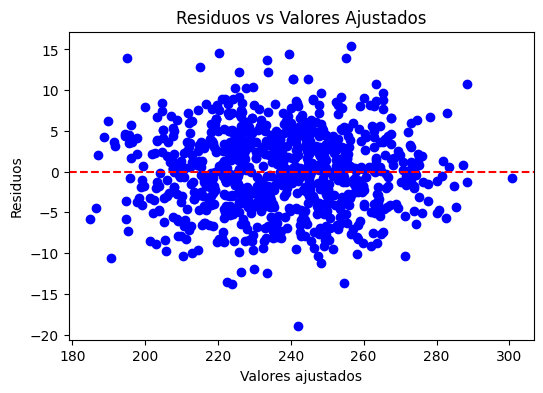


Diagnóstico de Linealidad
- Los residuos deben distribuirse aleatoriamente alrededor de 0.
- No deben observarse patrones curvos.
- Curvaturas sugieren no linealidad.


In [11]:
f_linealidad(modelo_RLM)


#### Prueba de Ramsey Test

Se ejecuta la función *f_linealidad_test(modelo_RLM)* la cual devuevle los estad´siticos y el diagnósticp de lña prueba de Ramsey RESET.


In [12]:
f_linealidad_test(modelo_RLM)


Test de Linealidad (Ramsey RESET)
<F test: F=0.062252685222849, p=0.8030320745793886, df_denom=829, df_num=1>

Interpretación:
✔ No se rechaza H0 → El modelo es lineal (no hay evidencia de curvatura)


<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=0.062252685222849, p=0.8030320745793886, df_denom=829, df_num=1>

###

### Homocedasticidad



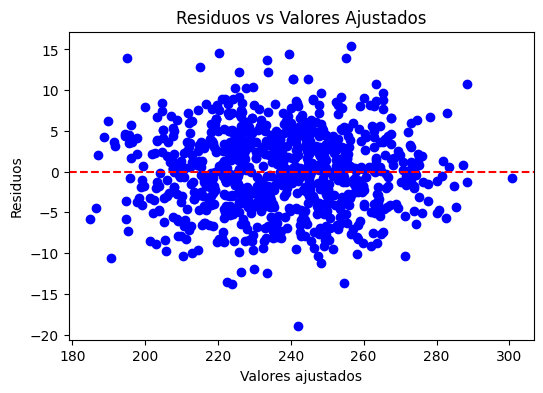


Diagnóstico de Homocedasticidad
          Prueba  LM Statistic  LM p-value  F Statistic  F p-value
0  Breusch-Pagan        4.9255      0.8408       0.5439     0.8428

Interpretación:
✔ No se rechaza H0 → Existe homocedasticidad


,Prueba,LM Statistic,LM p-value,F Statistic,F p-value
0,Breusch-Pagan,4.9255,0.8408,0.5439,0.8428


In [13]:
f_homocedasticidad(modelo_RLM)

### Normnalidad



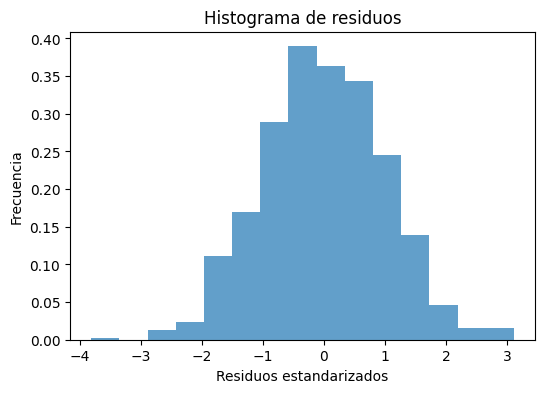

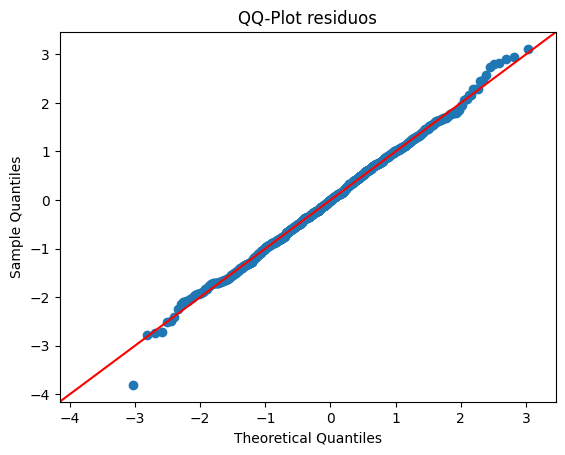


Diagnóstico de Normalidad
               Prueba  Estadistico  p_value Interpretacion
0        Shapiro-Wilk       0.9983    0.613     Normalidad
1  Kolmogorov-Smirnov       0.0169    0.966     Normalidad
2    Anderson-Darling       0.2444      NaN     Normalidad

Anderson-Darling:
Estadístico = 0.2444
Valor crítico 5% = 0.783

Interpretación:
✔ Shapiro-Wilk: Normalidad
✔ Kolmogorov-Smirnov: Normalidad
✔ Anderson-Darling: Normalidad


,Prueba,Estadistico,p_value,Interpretacion
0,Shapiro-Wilk,0.9983,0.613,Normalidad
1,Kolmogorov-Smirnov,0.0169,0.966,Normalidad
2,Anderson-Darling,0.2444,NaN,Normalidad


In [14]:
f_normalidad(modelo_RLM)

### Independencia de residuos

Ejecutando la función *f_independencia(modelo_RLM)* se observa en la FUGURA que se valida la independencia de residuos. La salida de las pruebas en modo consola:


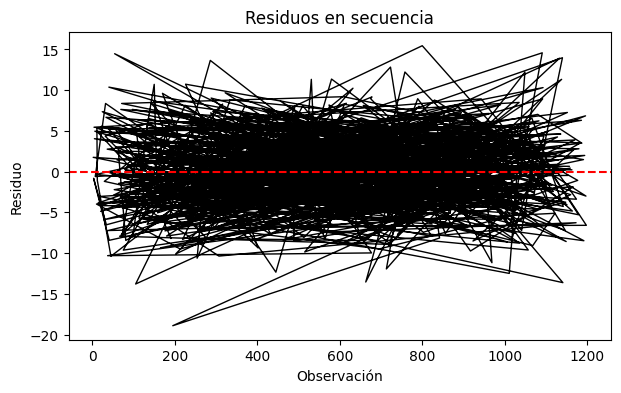


Diagnóstico de Independencia
          Prueba  Estadistico       Interpretacion
0  Durbin-Watson       2.0008  Sin autocorrelación

Interpretación:
✔ No existe evidencia de autocorrelación


,Prueba,Estadistico,Interpretacion
0,Durbin-Watson,2.0008,Sin autocorrelación


In [15]:
f_independencia(modelo_RLM)

## Ecuación del modelo



In [16]:
f_ecuacion_modelo(modelo_RLM)


ECUACIÓN DEL MODELO

ŷ = 49.5356 + 0.8534*temperatura + 0.5174*humedad + 0.3021*precipitacion + 0.5947*nitrogeno + 0.3964*fosforo + 2.7422*materia_organica + 1.1473*horas_sol + 2.6168*tipo_suelo_arenoso_True + 5.1034*tipo_suelo_franco_True


'ŷ = 49.5356 + 0.8534*temperatura + 0.5174*humedad + 0.3021*precipitacion + 0.5947*nitrogeno + 0.3964*fosforo + 2.7422*materia_organica + 1.1473*horas_sol + 2.6168*tipo_suelo_arenoso_True + 5.1034*tipo_suelo_franco_True'

## Evaluación del modelo



In [17]:
f_evaluacion_modelo(modelo_RLM, datos_validacion, "calidad_frijol")


Evaluación del Modelo
   R_square  R_square_ajustado      MSE    RMSE     MAE
0    0.9474             0.9461  25.4335  5.0432  3.9931


,R_square,R_square_ajustado,MSE,RMSE,MAE
0,0.9474,0.9461,25.4335,5.0432,3.9931


# Inerpretación del caso de estudio

Se construyó un modelo de regresión lineal múltiple con datos que valoran de manera numérica la calidad de frijol.

Las particiones se hicieron *70%* para datos de entrenamiento y *30%* para datos de validación.

Se cargaron librerías y funciones adecuadas para el caso de estudio.

Los resultados arrojan que el modelo goza de calidad predictiva, satisface la expectativa inicial de sobrepasar el *85%* en el estadístico r swuare ajustado; además, el modelo satisface los postulados de regresión como no multicolinealidad en las variables, linealidad, homocedasticidad, normalidad e independencia de residuos.

Los resultados son similares a los que arroja R.